In [388]:
# Required
import matplotlib.pyplot as plt
import numpy as np
from math import sin, cos, tan, pi, atan, asin, degrees, radians

Figure Q3 shows four meshing gears having a module of 6mm and 20° pressure
angle. The 70 rpm, 5 kW motor is connected to Gear 1 ($N_1 = 100$) on shaft A which
couples in turn to Gear 2 ($N_2 = 80$) that directly drives Gear 3 ($N_3 = 50$) on shaft B. The
output Gear 4 ($N_4= 200$) is mounted on shaft C, which eventually drives a machine.


- Determine the magnitude and direction of speed for output Gear 4.
- Determine the tangential and radial forces between Gear 1 and 2 and between Gear 3 and 4.
- If the speed of Gear 4 increases by 40\%, evaluate the new power produced by Gear 3.


In [389]:
Power = 5000
n_1=70
module = 6
pressureAngle=radians(20)
N_1=100
N_2=80
N_3=50
N_4=200

i. Determine the magnitude and direction of speed for output Gear 4.



$$
\frac{n_4}{n_1}=\frac{n_4}{n_3} \times \frac{n_2}{n_1}\\

\frac{n_4}{n_1}=-\frac{N_3}{N_4} \times -\frac{N_1}{N_2}
$$

In [390]:
speed_ratio=(-N_1*N_3)/(-N_2*N_4)
print(f"Speed ratio: {speed_ratio:.4f}")

Speed ratio: 0.3125


In [391]:
n_4=n_1*speed_ratio
print(f"Speed of gear 4: {n_4:.2f} rpm")
print('Direction is reversed' if speed_ratio < 0 else 'Direction is same')

Speed of gear 4: 21.88 rpm
Direction is same


ii. Determine the tangential and radial forces between Gear 1 and 2 and between Gear 3 and 4.


In [392]:
d1 = module * N_1
d2 = module * N_2
d3 = module * N_3
d4 = module * N_4
r1 = d1 / 2
r2 = d2 / 2
r3 = d3 / 2
r4 = d4 / 2
print(f'd1={d1}, d2={d2}, d3={d3}, d4={d4}')
print(f'r1={r1}, r2={r2}, r3={r3}, r4={r4}')

d1=600, d2=480, d3=300, d4=1200
r1=300.0, r2=240.0, r3=150.0, r4=600.0


In [393]:
n_2 = n_1 * N_1 / N_2
n_3 = n_2
print(n_1, n_2, n_3, n_4)

70 87.5 87.5 21.875


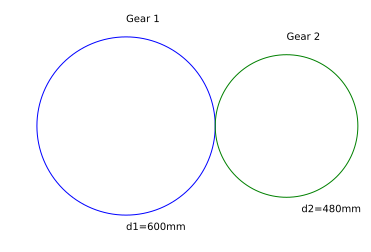

In [394]:
# Draw Gear
fig, ax = plt.subplots()

circle1 = plt.Circle((0, 0), r1/10, color='blue', fill=False)  
circle2 = plt.Circle((r1/10+r2/10, 0), r2/10, color='green', fill=False) 

ax.add_patch(circle1)
ax.add_patch(circle2)

ax.set_aspect('equal')
ax.axis('off')

ax.set_xlim(-40, 80)
ax.set_ylim(-40, 40)

# ax.set(title='Gear 1 and 2')
ax.text(0,r1/10+5,f'Gear 1')
ax.text(r1/10+r2/10,r2/10+5,f'Gear 2')
ax.text(0,-r1/10-5,f'd1={d1}mm')
ax.text(r1/10+r2/10+5,-r2/10-5,f'd2={d2}mm')
plt.show()

In [395]:
Torque=round(Power*60/(2*pi*n_1),2)
print(f'Torque={Torque} Nm')

Torque=682.09 Nm


In [396]:
print("r1 =", r1)

r1 = 300.0


In [397]:
Ft1=round(Torque/(r1/1000),2)
print(f'Tangential Force, Ft1={Ft1} N')

Tangential Force, Ft1=2273.63 N


In [398]:
Fr1=round(Ft1*tan(pressureAngle),2)
print(f'Fr1={Fr1}N')

Fr1=827.53N


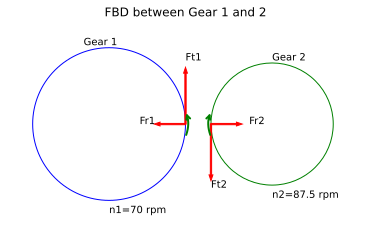

In [399]:
# FBD between Gear 1 and 2
fig, ax = plt.subplots()

offsetx=10
offsety=5

circle1 = plt.Circle((0, 0), r1/10, color='blue', fill=False)  
circle2 = plt.Circle((r1/10+r2/10+offsetx, 0), r2/10, color='green', fill=False) 

ax.add_patch(circle1)
ax.add_patch(circle2)

ax.set_aspect('equal')
ax.axis('off')

ax.set_xlim(-40, 100)
ax.set_ylim(-40, 40)

ax.set(title='FBD between Gear 1 and 2')
ax.text(0-offsetx,r1/10+1,f'Gear 1')
ax.text(r1/10+r2/10+offsetx,r2/10+1,f'Gear 2')
ax.text(0,-r1/10-offsety,f'n1={n_1} rpm')
ax.text(r1/10+r2/10+offsetx,-r2/10-offsety,f'n2={n_2:.1f} rpm')

ax.arrow(r1/10, 0, 0,20,width=0.5,color='r')
ax.text(r1/10,20+offsety,f'Ft1')
ax.arrow(r1/10, 0, -10,0,width=0.5,color='r')
ax.text(r1/10-18,0,f'Fr1')

ax.arrow(r1/10+offsetx, 0, 0,-20,width=0.5,color='r')
ax.text(r1/10+offsetx,-20-offsety,f'Ft2')
ax.arrow(r1/10+offsetx, 0, 10,0,width=0.5,color='r')
ax.text(r1/10+offsetx+15,0,f'Fr2')

ax.annotate("", xy=(r1/10, -5), xytext=(r1/10, 5),
            arrowprops=dict(arrowstyle="<-",
                            connectionstyle="arc3,rad=-0.2",
                            color="green", lw=2))
ax.annotate("", xy=(r1/10+offsetx, -5), xytext=(r1/10+offsetx, 5),
            arrowprops=dict(arrowstyle="<-",
                            connectionstyle="arc3,rad=0.2",
                            color="green", lw=2))
plt.show()

In [400]:
print(f'n3={n_3:.1f}rpm')
Torque3=round(Power*60/(2*pi*n_3),2)
print(f'Torque={Torque3} Nm')

n3=87.5rpm
Torque=545.67 Nm


In [401]:
Ft3 = round(Torque3/(r3/1000),2)
print(f'Ft3={Ft3} N')

Ft3=3637.8 N


In [402]:
Fr3=round(Ft3*tan(pressureAngle),2)
print(f'Fr3={Fr3} N')

Fr3=1324.05 N


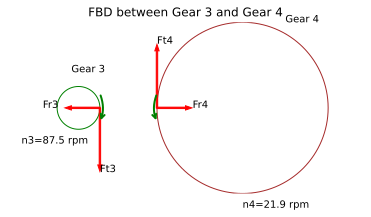

In [409]:
# FBD between Gear 3 and 4
fig, ax = plt.subplots()

offsetx=40
offsety=10

circle1 = plt.Circle((0, 0), r3/10, color='green', fill=False)  
circle2 = plt.Circle((r3/10+r4/10+offsetx, 0), r4/10, color='brown', fill=False) 

ax.add_patch(circle1)
ax.add_patch(circle2)

ax.set_aspect('equal')
ax.axis('off')

ax.set_xlim(-50, 200)
ax.set_ylim(-60, 60)

ax.set(title='FBD between Gear 3 and Gear 4')
ax.text(-5,r3/10+offsety,f'Gear 3')
ax.text(r3/10+r4/10+offsetx+30,r4/10,f'Gear 4')
ax.text(-offsetx,-r3/10-offsety,f'n3={n_3:.1f} rpm')
ax.text(r3/10+r4/10+offsetx,-r4/10-offsety,f'n4={n_4:.1f} rpm')

ax.arrow(r3/10, 0, 0,-40,width=1,color='r')
ax.text(r3/10,-45,f'Ft3')
ax.arrow(r3/10, 0, -20,0,width=1,color='r')
ax.text(r3/10-offsetx,0,f'Fr3')

ax.arrow(r3/10+offsetx, 0, 0,40,width=1,color='r')
ax.text(r3/10+offsetx,45,f'Ft4')
ax.arrow(r3/10+offsetx, 0, 20,0,width=1,color='r')
ax.text(r3/10+offsetx+25,0,f'Fr4')

ax.annotate("", xy=(r3/10, 10), xytext=(r3/10, -10),
            arrowprops=dict(arrowstyle="<-",
                            connectionstyle="arc3,rad=0.2",
                            color="green", lw=2))
ax.annotate("", xy=(r3/10+offsetx, -10), xytext=(r3/10+offsetx, 10),
            arrowprops=dict(arrowstyle="->",
                            connectionstyle="arc3,rad=0.2",
                            color="green", lw=2))
plt.show()

If the speed of Gear 4 increases by 40\%, evaluate the new power produced by Gear 3.

In [404]:
new_n_4 = 1.4 * n_4
print(f'new n_4={new_n_4:.1f} rpm')

new n_4=30.6 rpm
